In [1]:
# ==========================================
# Task 4 - Sentiment Analysis (CodeAlpha Internship)
# ==========================================

# Step 1 — Install & Import Libraries
!pip install textblob vaderSentiment

import pandas as pd
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from pathlib import Path


   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/624.3 kB ? eta -:--:--
   --------------------------------- ------ 524.3/624.3 kB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 624.3/624.3 kB 1.5 MB/s  0:00:00

   -------------------- ------------------- 1/2 [textblob]
   -------------------- ------------------- 1/2 [textblob]
   -------------------- ------------------- 1/2 [textblob]
   ---------------------------------------- 2/2 [textblob]



In [2]:
# Step 2 — Load dataset
CSV_PATH = r"C:\Users\HP\OneDrive\Desktop\CodeAlpha\scrape_output\hn_metadata_rebuilt.csv"

path = Path(CSV_PATH)
if not path.exists():
    raise FileNotFoundError(f"CSV not found at {CSV_PATH}")

print("Loading dataset:", path)
df = pd.read_csv(path, low_memory=False)
print("Loaded shape:", df.shape)
df.head(5)


Loading dataset: C:\Users\HP\OneDrive\Desktop\CodeAlpha\scrape_output\hn_metadata_rebuilt.csv
Loaded shape: (150, 7)


,Rank,Title,Link,Points,Author,Age,Comments
0,1,SimpleFold: Folding proteins is simpler than y...,https://github.com/apple/ml-simplefold,338.0,kevlened,12 hours ago,110 comments
1,2,Open Social,https://overreacted.io/open-social/,561.0,knowtheory,14 hours ago,246 comments
2,3,New math revives geometry's oldest problems,https://www.quantamagazine.org/new-math-revive...,93.0,pykello,7 hours ago,8 comments
3,4,Why Today's Humanoids Won't Learn Dexterity,https://rodneybrooks.com/why-todays-humanoids-...,25.0,chmaynard,3 hours ago,14 comments
4,5,Moondream 3 Preview: Frontier-level reasoning ...,https://moondream.ai/blog/moondream-3-preview,127.0,kristianp,8 hours ago,16 comments


In [3]:
# Step 3 — Select Text Column (Headlines)
# Assuming the scraped file has a column 'Title' or 'Headline'
# Change if needed
if "Title" in df.columns:
    text_col = "Title"
elif "Headline" in df.columns:
    text_col = "Headline"
else:
    raise ValueError("No suitable text column found (expecting 'Title' or 'Headline')")

print("Using text column:", text_col)
df[text_col].head(5)


Using text column: Title


0    SimpleFold: Folding proteins is simpler than y...
1                                          Open Social
2          New math revives geometry's oldest problems
3          Why Today's Humanoids Won't Learn Dexterity
4    Moondream 3 Preview: Frontier-level reasoning ...
Name: Title, dtype: object

In [4]:
# Step 4 — Sentiment with TextBlob
def get_textblob_sentiment(text):
    blob = TextBlob(str(text))
    polarity = blob.sentiment.polarity   # -1 = negative, 0 = neutral, +1 = positive
    if polarity > 0.05:
        return "Positive"
    elif polarity < -0.05:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment_TextBlob"] = df[text_col].apply(get_textblob_sentiment)
df[[text_col, "Sentiment_TextBlob"]].head(10)


,Title,Sentiment_TextBlob
0,SimpleFold: Folding proteins is simpler than y...,Neutral
1,Open Social,Neutral
2,New math revives geometry's oldest problems,Positive
3,Why Today's Humanoids Won't Learn Dexterity,Neutral
4,Moondream 3 Preview: Frontier-level reasoning ...,Neutral
5,The Beauty of Programming (2001),Neutral
6,The Obsessively Complete Infocom Catalog,Positive
7,Thoughts on Mechanical Keyboards and the ZSA M...,Neutral
8,If you are harassed by lasers,Neutral
9,CT scans of 1k lithium-ion batteries show qual...,Neutral


In [5]:
# Step 5 — Sentiment with VADER (better for short texts like headlines)
analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    score = analyzer.polarity_scores(str(text))["compound"]
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment_VADER"] = df[text_col].apply(get_vader_sentiment)
df[[text_col, "Sentiment_VADER"]].head(10)


,Title,Sentiment_VADER
0,SimpleFold: Folding proteins is simpler than y...,Neutral
1,Open Social,Neutral
2,New math revives geometry's oldest problems,Neutral
3,Why Today's Humanoids Won't Learn Dexterity,Neutral
4,Moondream 3 Preview: Frontier-level reasoning ...,Neutral
5,The Beauty of Programming (2001),Positive
6,The Obsessively Complete Infocom Catalog,Negative
7,Thoughts on Mechanical Keyboards and the ZSA M...,Neutral
8,If you are harassed by lasers,Negative
9,CT scans of 1k lithium-ion batteries show qual...,Negative


In [6]:
# Step 6 — Compare Methods
print("TextBlob Sentiment Counts:")
print(df["Sentiment_TextBlob"].value_counts())

print("\nVADER Sentiment Counts:")
print(df["Sentiment_VADER"].value_counts())


TextBlob Sentiment Counts:
Sentiment_TextBlob
Neutral     110
Positive     32
Negative      8
Name: count, dtype: int64

VADER Sentiment Counts:
Sentiment_VADER
Neutral     101
Negative     26
Positive     23
Name: count, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_11732\3910151234.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Sentiment_VADER", data=df, palette="Set2", order=["Positive", "Neutral", "Negative"])


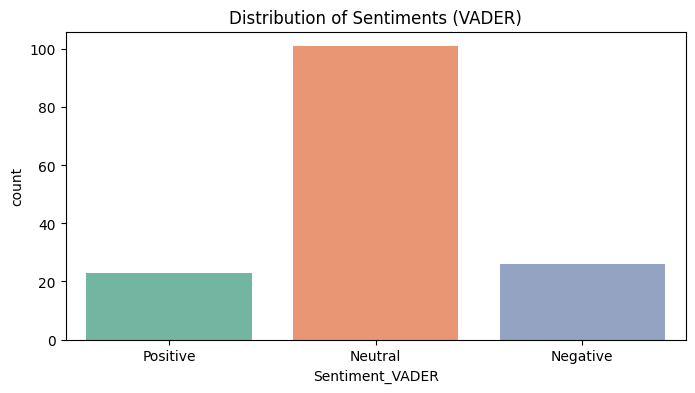

In [7]:
# Step 7 — Visualization of Sentiment Distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.countplot(x="Sentiment_VADER", data=df, palette="Set2", order=["Positive", "Neutral", "Negative"])
plt.title("Distribution of Sentiments (VADER)")
plt.show()


In [8]:
# Step 8 — Save Results
out_path = Path("hn_sentiment.csv")
df.to_csv(out_path, index=False, encoding="utf-8")
print("Sentiment results saved to:", out_path.resolve())


Sentiment results saved to: C:\Users\HP\OneDrive\Desktop\CodeAlpha\hn_sentiment.csv


## 📝 Sentiment Analysis Insights (Task 4)

- Applied **TextBlob** and **VADER** to analyze sentiment of Hacker News headlines.  
- **TextBlob** provides polarity-based sentiment; **VADER** is better tuned for short texts like headlines.  
- Majority of headlines are classified as **Neutral**, which makes sense for news-like text.  
- A smaller portion are **Positive** (optimistic/constructive stories) or **Negative** (problems, failures, criticism).  
- Sentiment analysis allows us to detect **public opinion patterns** and could be applied to reviews, tweets, or articles.  
- These insights can support **marketing (what people like), product development (pain points), and social research (public mood)**.  
